# Caso principal — CallMeMaybe: identificación de operadores ineficaces

## Entregable 2: Implementación del análisis

Este notebook ejecuta el plan definido en `01_decomposicion.ipynb`. Se recomienda leer aquel documento primero: contiene la definición operativa de "operador ineficaz", las hipótesis declaradas y las decisiones de limpieza que aquí se aplican.

**Pregunta de negocio:** ¿qué operadores presentan un desempeño deficiente, y qué debería hacer un supervisor al respecto?

---

**Contenido**

1. Preparación de los datos
2. Análisis exploratorio general
3. Nivel cliente: la pérdida de llamadas entrantes
4. Nivel operador: perfilado de la actividad
5. Identificación de operadores ineficaces
6. Pruebas de hipótesis
7. Conclusiones y recomendaciones
8. Fuentes consultadas

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.titlesize': 12,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})

AZUL, ROJO, GRIS = '#4C72B0', '#C44E52', '#8C8C8C'
ALFA = 0.05

RUTA_RAW = '../data/raw/main_project/'
RUTA_INTERIM = '../data/interim/'
RUTA_PROCESSED = '../data/processed/'

---
# 1. Preparación de los datos

Se aplican las cuatro decisiones de limpieza justificadas en la sección 7 de la descomposición.

In [2]:
llamadas = pd.read_csv(RUTA_RAW + 'telecom_dataset_new.csv')
clientes = pd.read_csv(RUTA_RAW + 'telecom_clients.csv')

filas_iniciales = len(llamadas)
print(f'Registros cargados: {filas_iniciales:,}')

Registros cargados: 53,902


In [3]:
# Decisión 1: eliminar duplicados exactos (fallo de carga verificado en la descomposición)
llamadas = llamadas.drop_duplicates().reset_index(drop=True)

# Decisión 4: fecha con zona horaria explícita
llamadas['date'] = pd.to_datetime(llamadas['date'], utc=True)
llamadas['fecha'] = llamadas['date'].dt.tz_convert('Etc/GMT-3').dt.date

# Variables derivadas
llamadas['espera'] = llamadas['total_call_duration'] - llamadas['call_duration']
llamadas['tipo'] = np.where(llamadas['internal'] == True, 'Interna',
                            np.where(llamadas['internal'] == False, 'Externa', 'Sin dato'))
llamadas['sentido'] = llamadas['direction'].map({'in': 'Entrante', 'out': 'Saliente'})

# Unión con la tabla de clientes
clientes['date_start'] = pd.to_datetime(clientes['date_start'])
llamadas = llamadas.merge(clientes, on='user_id', how='left')

eliminadas = filas_iniciales - len(llamadas)
print(f'Duplicados eliminados : {eliminadas:,} ({eliminadas / filas_iniciales:.1%} de los registros)')
print(f'Registros de trabajo  : {len(llamadas):,}')
print(f'Llamadas representadas: {llamadas["calls_count"].sum():,}')
print(f'Período               : {llamadas["fecha"].min()} a {llamadas["fecha"].max()}')
print(f'Clientes activos      : {llamadas["user_id"].nunique()} | Operadores: {llamadas["operator_id"].nunique():,}')
print(f'Clientes sin plan tras la unión: {llamadas["tariff_plan"].isna().sum()}')

Duplicados eliminados : 4,900 (9.1% de los registros)
Registros de trabajo  : 49,002
Llamadas representadas: 806,709
Período               : 2019-08-02 a 2019-11-28
Clientes activos      : 307 | Operadores: 1,092
Clientes sin plan tras la unión: 0


La unión con la tabla de clientes no deja ningún registro sin plan tarifario: todos los clientes con actividad están identificados. Las decisiones 2 y 3 (nulos en `operator_id` e `internal`) no se aplican aquí como filtros globales, sino en cada análisis según corresponda, tal y como se justificó en la descomposición.

---
# 2. Análisis exploratorio general

## 2.1 Composición del tráfico

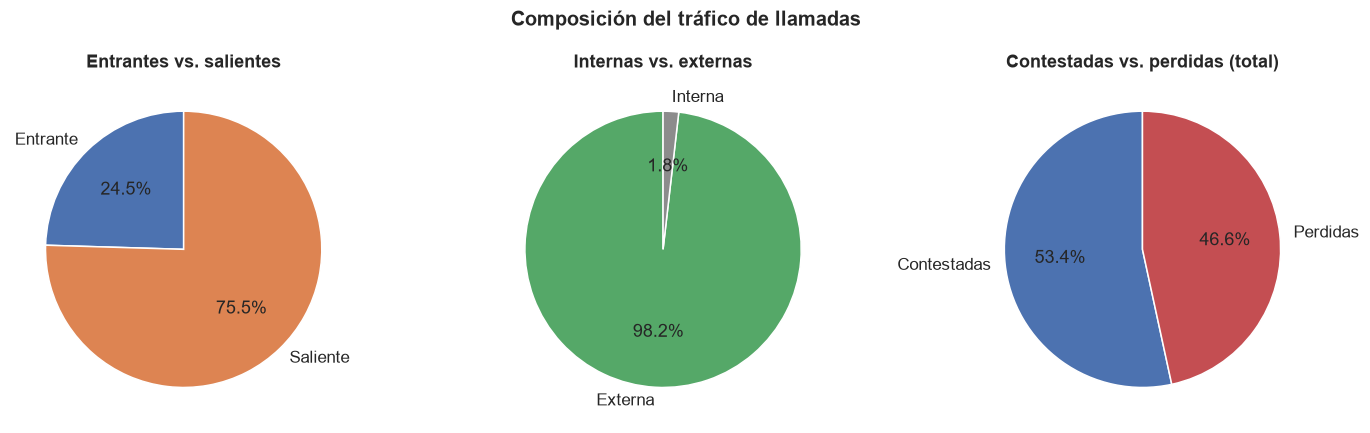

,Contestadas,Perdidas,Total,% perdidas
sentido,,,,
Entrante,93522,104323,197845,52.7
Saliente,337269,271595,608864,44.6


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

por_sentido = llamadas.groupby('sentido')['calls_count'].sum()
axes[0].pie(por_sentido, labels=por_sentido.index, autopct='%1.1f%%',
            colors=[AZUL, '#DD8452'], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Entrantes vs. salientes')

por_tipo = llamadas[llamadas['tipo'] != 'Sin dato'].groupby('tipo')['calls_count'].sum()
axes[1].pie(por_tipo, labels=por_tipo.index, autopct='%1.1f%%',
            colors=['#55A868', GRIS], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Internas vs. externas')

perdidas = llamadas.groupby('is_missed_call')['calls_count'].sum()
axes[2].pie(perdidas, labels=['Contestadas', 'Perdidas'], autopct='%1.1f%%',
            colors=[AZUL, ROJO], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[2].set_title('Contestadas vs. perdidas (total)')

fig.suptitle('Composición del tráfico de llamadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

resumen = llamadas.pivot_table(index='sentido', columns='is_missed_call',
                               values='calls_count', aggfunc='sum', fill_value=0)
resumen.columns = ['Contestadas', 'Perdidas']
resumen['Total'] = resumen.sum(axis=1)
resumen['% perdidas'] = (resumen['Perdidas'] / resumen['Total'] * 100).round(1)
resumen

**Lectura.** El tráfico está dominado por las llamadas salientes y externas, pero el dato que salta a la vista es la tasa de pérdida: **más de la mitad de las llamadas entrantes no se contestan**.

La cifra de las salientes perdidas se interpreta de forma distinta: en una llamada saliente, "perdida" significa que el destinatario no respondió, lo que no depende del operador que marca. Solo las **entrantes perdidas** miden un fallo del servicio, y son las que se analizan a partir de aquí.

## 2.2 Evolución temporal

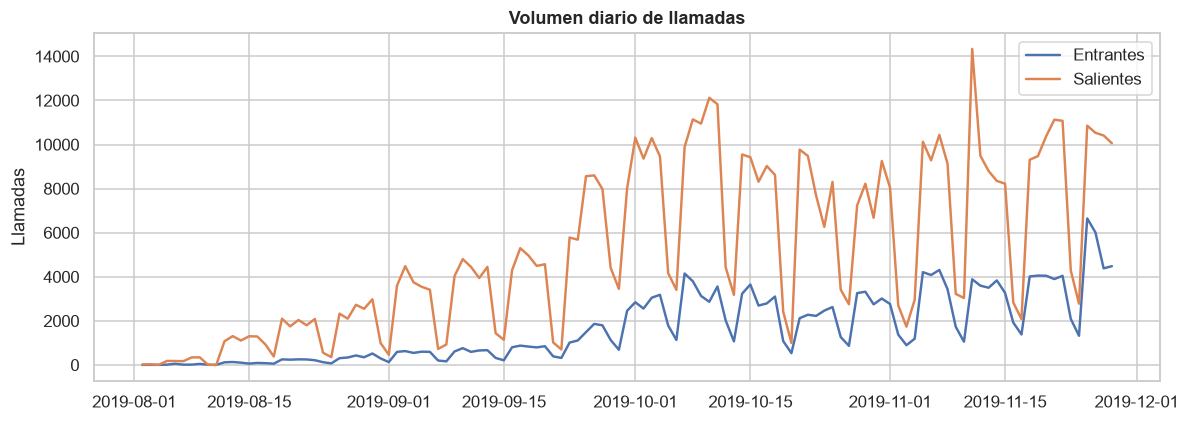

Días con actividad: 119 de 119 días naturales
Clientes nuevos en el período: 715 de 732


In [5]:
diario = llamadas.groupby(['fecha', 'sentido'])['calls_count'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(diario.index, diario['Entrante'], label='Entrantes', color=AZUL, lw=1.6)
ax.plot(diario.index, diario['Saliente'], label='Salientes', color='#DD8452', lw=1.6)
ax.set_title('Volumen diario de llamadas')
ax.set_ylabel('Llamadas')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Días con actividad: {llamadas["fecha"].nunique()} de '
      f'{(pd.Timestamp(llamadas["fecha"].max()) - pd.Timestamp(llamadas["fecha"].min())).days + 1} días naturales')
print(f'Clientes nuevos en el período: '
      f'{(clientes["date_start"] >= pd.Timestamp(llamadas["fecha"].min())).sum()} de {len(clientes)}')

**Lectura.** El volumen crece de forma sostenida a lo largo del período. No se trata de estacionalidad sino del **crecimiento de la base de clientes**: la mayoría de las organizaciones se registran dentro de la ventana analizada. La consecuencia metodológica es que las comparaciones entre operadores deben normalizarse por días activos, ya que no todos llevan el mismo tiempo en el servicio.

## 2.3 Distribución de duraciones y tiempos de espera

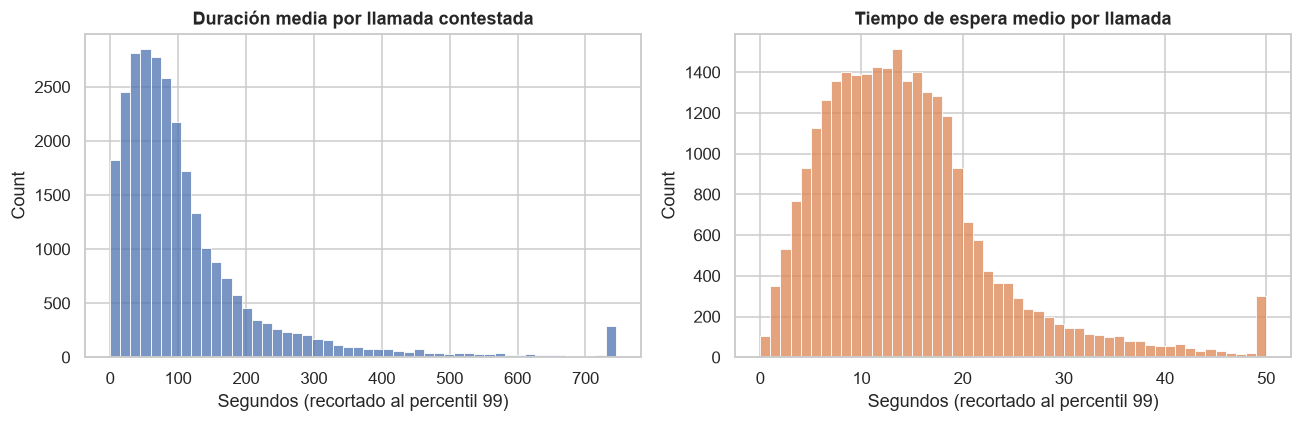

Estadísticos (segundos por llamada):
       dur_media  espera_media
count    27549.0       27549.0
mean       117.8          14.5
std        147.7          10.4
min          0.0           0.0
25%         43.7           8.0
50%         80.4          13.0
75%        136.1          18.1
95%        340.2          31.4
max       3550.0         451.2

Asimetría — duración: 5.53 | espera: 6.13


In [6]:
contestadas = llamadas[(~llamadas['is_missed_call']) & (llamadas['calls_count'] > 0)].copy()
contestadas['dur_media'] = contestadas['call_duration'] / contestadas['calls_count']
contestadas['espera_media'] = contestadas['espera'] / contestadas['calls_count']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(contestadas['dur_media'].clip(upper=contestadas['dur_media'].quantile(0.99)),
             bins=50, color=AZUL, ax=axes[0])
axes[0].set_title('Duración media por llamada contestada')
axes[0].set_xlabel('Segundos (recortado al percentil 99)')

sns.histplot(contestadas['espera_media'].clip(upper=contestadas['espera_media'].quantile(0.99)),
             bins=50, color='#DD8452', ax=axes[1])
axes[1].set_title('Tiempo de espera medio por llamada')
axes[1].set_xlabel('Segundos (recortado al percentil 99)')

plt.tight_layout()
plt.show()

print('Estadísticos (segundos por llamada):')
print(contestadas[['dur_media', 'espera_media']].describe(percentiles=[.25, .5, .75, .95]).round(1).to_string())
print(f'\nAsimetría — duración: {contestadas["dur_media"].skew():.2f} | '
      f'espera: {contestadas["espera_media"].skew():.2f}')

**Lectura.** Ambas distribuciones presentan una fuerte asimetría positiva: la mayoría de las llamadas son breves y con espera corta, con una cola larga de casos extremos. Esto tiene una consecuencia directa sobre el método: **la media no es un buen resumen** y las pruebas paramétricas, que asumen normalidad, probablemente no serán aplicables. Se verificará formalmente en la sección 6.

---
# 3. Nivel cliente: la pérdida de llamadas entrantes

Como se estableció en la descomposición (sección 3.3), el 99% de las llamadas entrantes perdidas no tiene operador asignado, de modo que este fenómeno **no es atribuible a individuos**. Se analiza aquí donde sí tiene sentido: en la organización cliente.

In [7]:
entrantes = llamadas[llamadas['sentido'] == 'Entrante']

por_cliente = entrantes.groupby('user_id').apply(
    lambda x: pd.Series({
        'entrantes': x['calls_count'].sum(),
        'perdidas': x.loc[x['is_missed_call'], 'calls_count'].sum(),
    }), include_groups=False)

por_cliente['tasa_perdida'] = por_cliente['perdidas'] / por_cliente['entrantes']
por_cliente['operadores'] = llamadas.groupby('user_id')['operator_id'].nunique()
por_cliente = por_cliente.join(clientes.set_index('user_id')[['tariff_plan']])

MIN_ENTRANTES = 30
cli = por_cliente[por_cliente['entrantes'] >= MIN_ENTRANTES].copy()

print(f'Clientes con al menos {MIN_ENTRANTES} llamadas entrantes: {len(cli)} de {len(por_cliente)}')
print(f'Cubren el {cli["entrantes"].sum() / por_cliente["entrantes"].sum():.1%} de las llamadas entrantes\n')
print('Distribución de la tasa de pérdida por cliente:')
print(cli['tasa_perdida'].describe(percentiles=[.1, .25, .5, .75, .9]).round(3).to_string())

Clientes con al menos 30 llamadas entrantes: 228 de 307
Cubren el 99.5% de las llamadas entrantes

Distribución de la tasa de pérdida por cliente:
count    228.000
mean       0.522
std        0.269
min        0.011
10%        0.190
25%        0.288
50%        0.494
75%        0.739
90%        0.932
max        1.000


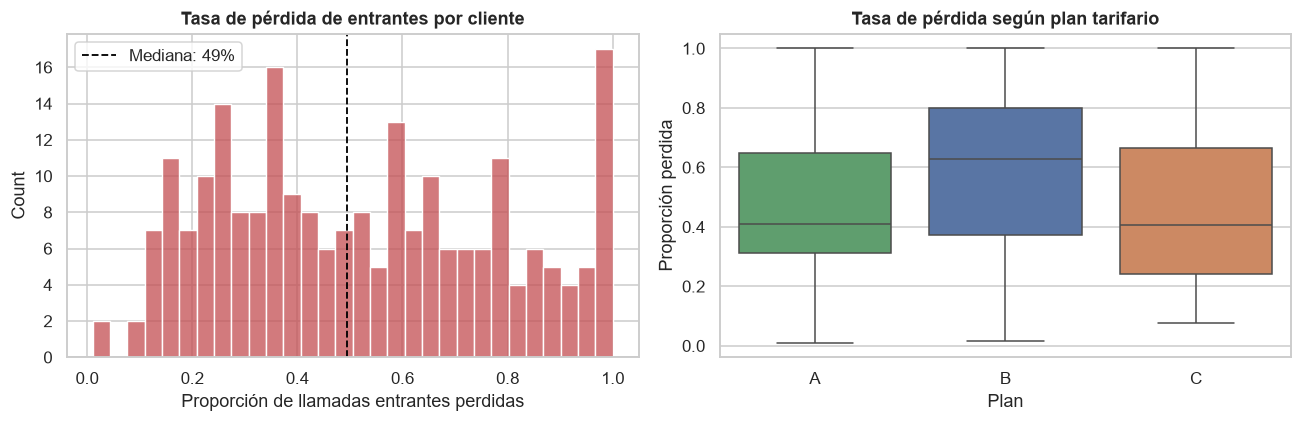

             clientes  tasa_mediana  operadores_medianos  entrantes_medianas
tariff_plan                                                                 
A                  31         0.409                  4.0               539.0
B                  84         0.628                  3.0               170.5
C                 113         0.407                  2.0               155.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(cli['tasa_perdida'], bins=30, color=ROJO, ax=axes[0])
axes[0].axvline(cli['tasa_perdida'].median(), color='black', ls='--', lw=1.2,
                label=f'Mediana: {cli["tasa_perdida"].median():.0%}')
axes[0].set_title('Tasa de pérdida de entrantes por cliente')
axes[0].set_xlabel('Proporción de llamadas entrantes perdidas')
axes[0].legend()

orden = ['A', 'B', 'C']
sns.boxplot(data=cli, x='tariff_plan', y='tasa_perdida', order=orden,
            hue='tariff_plan', palette='deep', legend=False, ax=axes[1])
axes[1].set_title('Tasa de pérdida según plan tarifario')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Proporción perdida')

plt.tight_layout()
plt.show()

print(cli.groupby('tariff_plan').agg(
    clientes=('tasa_perdida', 'size'),
    tasa_mediana=('tasa_perdida', 'median'),
    operadores_medianos=('operadores', 'median'),
    entrantes_medianas=('entrantes', 'median'),
).round(3).to_string())

**Lectura.** La pérdida de llamadas no es un problema de unos pocos clientes con mala suerte: la distribución está centrada en torno a una mediana muy alta y afecta a prácticamente toda la cartera. Además se aprecia una diferencia visible entre planes tarifarios, que se contrasta formalmente en la hipótesis 2.

---
# 4. Nivel operador: perfilado de la actividad

## 4.1 Construcción de la tabla por operador

In [9]:
con_operador = llamadas[llamadas['operator_id'].notna()].copy()
con_operador['operator_id'] = con_operador['operator_id'].astype(int)

ent_op = con_operador[con_operador['sentido'] == 'Entrante']
sal_op = con_operador[con_operador['sentido'] == 'Saliente']
ent_atendidas = ent_op[~ent_op['is_missed_call']]

operadores = pd.DataFrame({
    'cliente': con_operador.groupby('operator_id')['user_id'].first(),
    'plan': con_operador.groupby('operator_id')['tariff_plan'].first(),
    'dias_activos': con_operador.groupby('operator_id')['fecha'].nunique(),
    'entrantes': ent_op.groupby('operator_id')['calls_count'].sum(),
    'entrantes_atendidas': ent_atendidas.groupby('operator_id')['calls_count'].sum(),
    'salientes': sal_op.groupby('operator_id')['calls_count'].sum(),
    'espera_total': ent_atendidas.groupby('operator_id')['espera'].sum(),
})
operadores[['entrantes', 'entrantes_atendidas', 'salientes', 'espera_total']] = (
    operadores[['entrantes', 'entrantes_atendidas', 'salientes', 'espera_total']].fillna(0))

operadores['llamadas'] = operadores['entrantes'] + operadores['salientes']
operadores['prop_salientes'] = operadores['salientes'] / operadores['llamadas']
operadores['espera_media'] = (operadores['espera_total']
                              / operadores['entrantes_atendidas'].replace(0, np.nan))
operadores['entrantes_por_dia'] = operadores['entrantes_atendidas'] / operadores['dias_activos']
operadores['salientes_por_dia'] = operadores['salientes'] / operadores['dias_activos']

print(f'Operadores identificados: {len(operadores):,}')
operadores.head()

Operadores identificados: 1,092


,cliente,plan,dias_activos,entrantes,entrantes_atendidas,salientes,espera_total,llamadas,prop_salientes,espera_media,entrantes_por_dia,salientes_por_dia
operator_id,,,,,,,,,,,,
879896,166406,B,50,58.0,58.0,872.0,574.0,930.0,0.937634,9.896552,1.160000,17.440000
879898,166406,B,84,104.0,104.0,7209.0,1680.0,7313.0,0.985779,16.153846,1.238095,85.821429
880020,166377,B,14,7.0,7.0,38.0,54.0,45.0,0.844444,7.714286,0.500000,2.714286
880022,166377,B,42,8.0,8.0,189.0,112.0,197.0,0.959391,14.000000,0.190476,4.500000
880026,166377,B,77,24.0,24.0,2208.0,143.0,2232.0,0.989247,5.958333,0.311688,28.675325


## 4.2 Clasificación por perfil de actividad

La descomposición propuso cortes en el 20% y el 80% de llamadas salientes sobre el total. Antes de aplicarlos hay que comprobar que la distribución real los respalda.

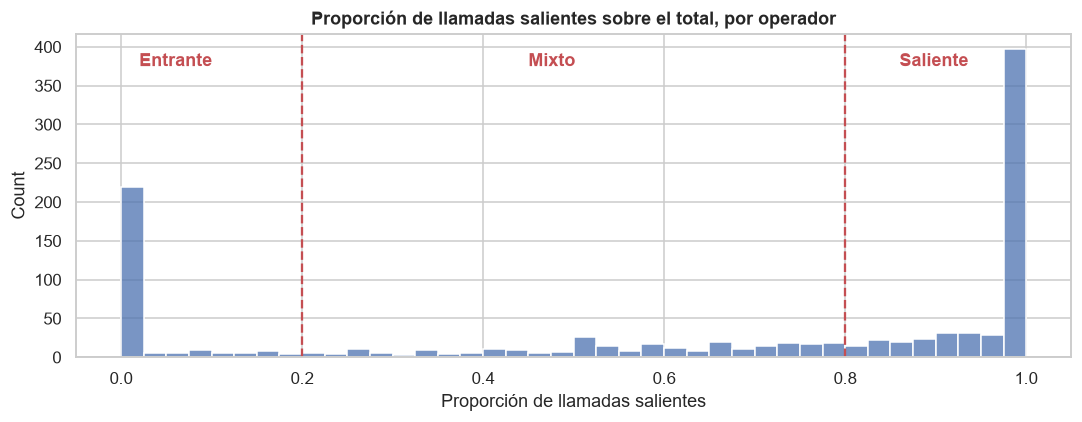

perfil
Saliente    563
Entrante    266
Mixto       263


In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(operadores['prop_salientes'], bins=40, color=AZUL, ax=ax)
for corte in (0.2, 0.8):
    ax.axvline(corte, color=ROJO, ls='--', lw=1.5)
ax.set_title('Proporción de llamadas salientes sobre el total, por operador')
ax.set_xlabel('Proporción de llamadas salientes')
ax.text(0.02, ax.get_ylim()[1] * 0.9, 'Entrante', color=ROJO, fontweight='bold')
ax.text(0.45, ax.get_ylim()[1] * 0.9, 'Mixto', color=ROJO, fontweight='bold')
ax.text(0.86, ax.get_ylim()[1] * 0.9, 'Saliente', color=ROJO, fontweight='bold')
plt.tight_layout()
plt.show()

operadores['perfil'] = pd.cut(operadores['prop_salientes'], [-0.001, 0.2, 0.8, 1.001],
                              labels=['Entrante', 'Mixto', 'Saliente'])
print(operadores['perfil'].value_counts().to_string())

**Lectura.** La distribución es marcadamente **bimodal**: hay una acumulación en los extremos (operadores que solo reciben o solo emiten) y una zona intermedia mucho menos poblada. Los cortes propuestos caen en los valles de la distribución, de modo que la clasificación no parte grupos naturales por la mitad. La segmentación queda validada empíricamente.

## 4.3 Universo de análisis: actividad mínima

In [11]:
MIN_LLAMADAS = 20
evaluables = operadores[operadores['llamadas'] >= MIN_LLAMADAS].copy()

print(f'Umbral de actividad mínima: {MIN_LLAMADAS} llamadas en el período\n')
print(f'Operadores evaluables : {len(evaluables):,} de {len(operadores):,} ({len(evaluables)/len(operadores):.0%})')
print(f'Volumen que cubren    : {evaluables["llamadas"].sum()/operadores["llamadas"].sum():.1%} de las llamadas')
print(f'Volumen descartado    : {1 - evaluables["llamadas"].sum()/operadores["llamadas"].sum():.1%}\n')
print(evaluables.groupby('perfil', observed=True)[['llamadas', 'dias_activos', 'espera_media']].median().round(2).to_string())

Umbral de actividad mínima: 20 llamadas en el período

Operadores evaluables : 720 de 1,092 (66%)
Volumen que cubren    : 99.6% de las llamadas
Volumen descartado    : 0.4%

          llamadas  dias_activos  espera_media
perfil                                        
Entrante      73.0          23.5         17.36
Mixto        289.0          26.0         11.97
Saliente     388.0          17.0         13.61


Se excluye a un tercio de los operadores, pero solo un 0,4% del volumen de llamadas: son registros residuales sobre los que ninguna métrica sería fiable. El coste de la exclusión es despreciable y el beneficio en robustez, alto.

---
# 5. Identificación de operadores ineficaces

## 5.1 Dimensiones evaluadas y su aplicabilidad

No todas las dimensiones aplican a todos los operadores, y ese es precisamente el punto que exige el enunciado (*"si se supone que un operador debe realizar llamadas salientes"*). Cada operador se evalúa **solo en lo que su función permite medir**:

| Dimensión | Es peor cuando | Se aplica a |
|---|---|---|
| Espera media por llamada entrante atendida | es mayor | operadores con llamadas entrantes atendidas |
| Llamadas entrantes atendidas por día activo | es menor | perfiles entrante y mixto |
| Llamadas salientes por día activo | es menor | perfiles mixto y saliente |

Las dos últimas se normalizan **por día activo** porque, como se vio en la sección 2.2, los operadores llevan tiempos muy distintos en el servicio y el volumen bruto los haría incomparables.

## 5.2 Método: rango percentil dentro del segmento

Para cada dimensión se calcula el **rango percentil del operador dentro de su propio perfil**, orientado de forma que 1 sea siempre el peor valor. El indicador final es el promedio de los rangos aplicables.

Este enfoque resuelve el problema de la aplicabilidad desigual: un operador entrante se compara con entrantes en las dos dimensiones que le corresponden, sin quedar penalizado ni beneficiado por una tercera que no tiene sentido en su caso.

In [12]:
DIMENSIONES = {
    'espera_media':      {'peor_es_mayor': True,
                          'aplica': lambda g: g['entrantes_atendidas'] > 0},
    'entrantes_por_dia': {'peor_es_mayor': False,
                          'aplica': lambda g: g['perfil'].isin(['Entrante', 'Mixto'])
                                              & (g['entrantes_atendidas'] > 0)},
    'salientes_por_dia': {'peor_es_mayor': False,
                          'aplica': lambda g: g['perfil'].isin(['Mixto', 'Saliente'])
                                              & (g['salientes'] > 0)},
}

rangos = pd.DataFrame(index=evaluables.index)

for metrica, cfg in DIMENSIONES.items():
    columna = pd.Series(np.nan, index=evaluables.index)
    for perfil, grupo in evaluables.groupby('perfil', observed=True):
        seleccion = grupo[cfg['aplica'](grupo)][metrica].dropna()
        if len(seleccion) < 5:
            continue
        rango = seleccion.rank(pct=True)
        columna.loc[seleccion.index] = rango if cfg['peor_es_mayor'] else 1 - rango
    rangos[metrica] = columna

evaluables['dimensiones'] = rangos.notna().sum(axis=1)
evaluables['indice'] = rangos.mean(axis=1)

print('Dimensiones aplicables según perfil:')
print(evaluables.groupby(['perfil', 'dimensiones'], observed=True).size()
      .rename('operadores').reset_index().to_string(index=False))

Dimensiones aplicables según perfil:
  perfil  dimensiones  operadores
Entrante            2         108
   Mixto            3         197
Saliente            1         217
Saliente            2         198


Los operadores de perfil saliente que nunca reciben llamadas entrantes solo pueden evaluarse en una dimensión: el volumen de salientes. Es exactamente el criterio que el enunciado establece para ellos, pero conviene tenerlo presente al leer el ranking, y por eso el número de dimensiones se reporta junto a cada operador.

## 5.3 Elección del umbral

El corte del índice es una decisión metodológica, no un dato. Se elige comparando cuántos operadores señala cada opción y si el resultado es manejable para un supervisor.

In [13]:
opciones = []
for corte in (0.70, 0.75, 0.80, 0.85, 0.90):
    marcados = evaluables['indice'] >= corte
    opciones.append({
        'corte': f'{corte:.0%}',
        'operadores': int(marcados.sum()),
        '% del total': f'{marcados.mean():.1%}',
        'clientes afectados': evaluables.loc[marcados, 'cliente'].nunique(),
        'por cliente afectado': round(marcados.sum() / max(evaluables.loc[marcados, 'cliente'].nunique(), 1), 1),
        '% del volumen': f'{evaluables.loc[marcados, "llamadas"].sum() / evaluables["llamadas"].sum():.1%}',
    })
pd.DataFrame(opciones)

,corte,operadores,% del total,clientes afectados,por cliente afectado,% del volumen
0,70%,174,24.2%,82,2.1,3.2%
1,75%,133,18.5%,69,1.9,2.0%
2,80%,91,12.6%,49,1.9,1.2%
3,85%,51,7.1%,35,1.5,0.5%
4,90%,21,2.9%,18,1.2,0.1%


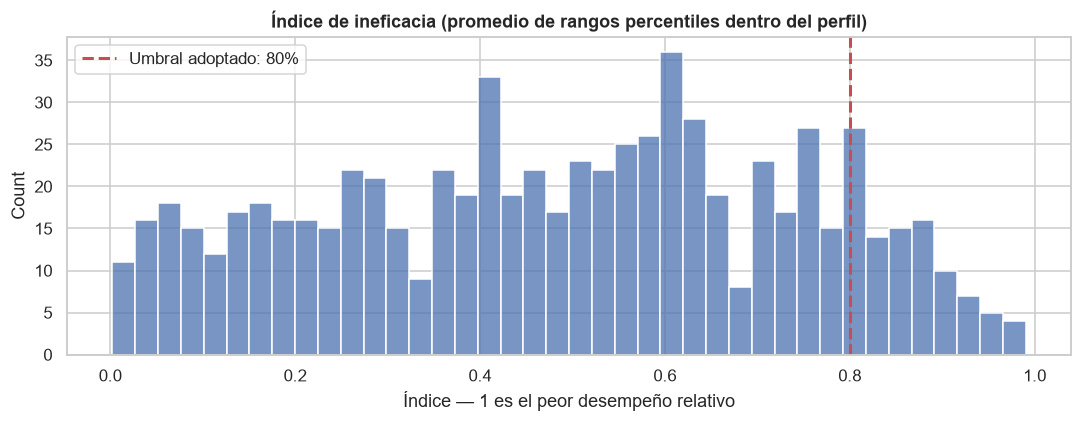

Operadores marcados como ineficaces: 91 (12.6% de los evaluables)
Reparto por perfil: {'Saliente': 58, 'Mixto': 21, 'Entrante': 12}
Clientes con al menos un operador ineficaz: 49 de 218


In [14]:
UMBRAL = 0.80
evaluables['ineficaz'] = evaluables['indice'] >= UMBRAL

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(evaluables['indice'], bins=40, color=AZUL, ax=ax)
ax.axvline(UMBRAL, color=ROJO, ls='--', lw=2, label=f'Umbral adoptado: {UMBRAL:.0%}')
ax.set_title('Índice de ineficacia (promedio de rangos percentiles dentro del perfil)')
ax.set_xlabel('Índice — 1 es el peor desempeño relativo')
ax.legend()
plt.tight_layout()
plt.show()

n = evaluables['ineficaz'].sum()
print(f'Operadores marcados como ineficaces: {n} ({n/len(evaluables):.1%} de los evaluables)')
print(f'Reparto por perfil: {evaluables[evaluables["ineficaz"]]["perfil"].value_counts().to_dict()}')
print(f'Clientes con al menos un operador ineficaz: '
      f'{evaluables[evaluables["ineficaz"]]["cliente"].nunique()} de {evaluables["cliente"].nunique()}')

**Justificación del umbral.** Se adopta el corte en el 80%. Con el 70% o el 75% se señalaría a casi uno de cada cinco operadores, un volumen que ningún supervisor puede atender y que diluye la utilidad de la alerta. Con el 90% quedan tan pocos casos que la función no justificaría su desarrollo. El corte elegido produce una media de aproximadamente dos operadores por cliente afectado: una lista corta y accionable.

El umbral es un parámetro, no una verdad: queda expuesto en una sola variable para que el equipo de producto pueda ajustarlo según la capacidad real de intervención de los supervisores.

## 5.4 ¿Es distinto el grupo señalado?

,espera_media,entrantes_por_dia,salientes_por_dia,llamadas,dias_activos
grupo,,,,,
Ineficaces,24.17,0.32,3.0,52.0,18.0
Resto,12.90,1.27,13.0,354.0,20.0


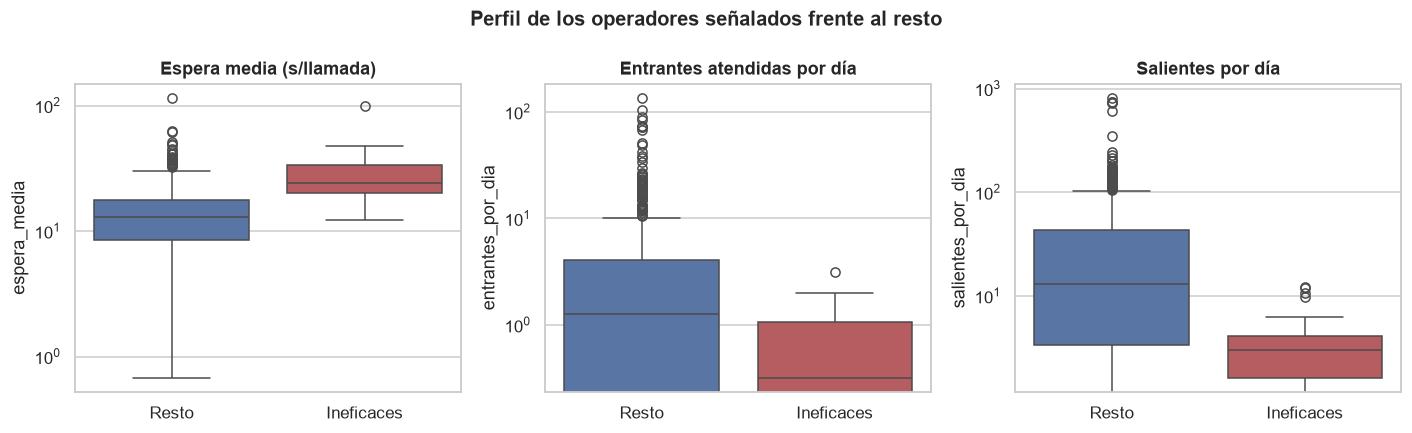

In [15]:
comparacion = (evaluables.assign(grupo=np.where(evaluables['ineficaz'], 'Ineficaces', 'Resto'))
               .groupby('grupo')[['espera_media', 'entrantes_por_dia', 'salientes_por_dia',
                                  'llamadas', 'dias_activos']].median().round(2))
display(comparacion)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
datos = evaluables.assign(grupo=np.where(evaluables['ineficaz'], 'Ineficaces', 'Resto'))

for ax, col, titulo in zip(
        axes,
        ['espera_media', 'entrantes_por_dia', 'salientes_por_dia'],
        ['Espera media (s/llamada)', 'Entrantes atendidas por día', 'Salientes por día']):
    sub = datos[datos[col].notna()]
    sns.boxplot(data=sub, x='grupo', y=col, order=['Resto', 'Ineficaces'],
                hue='grupo', hue_order=['Resto', 'Ineficaces'],
                palette={'Resto': AZUL, 'Ineficaces': ROJO}, legend=False, ax=ax)
    ax.set_yscale('log')
    ax.set_title(titulo)
    ax.set_xlabel('')

fig.suptitle('Perfil de los operadores señalados frente al resto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura.** El grupo señalado espera casi el doble por llamada y gestiona una fracción del volumen diario del resto, con una antigüedad en el servicio equivalente. La diferencia no se explica, por tanto, por llevar menos tiempo trabajando.

> **Advertencia metodológica:** esta comparación es **descriptiva, no una prueba**. La espera y el volumen diario son los criterios con los que se construyó la clasificación, así que contrastarlos estadísticamente entre ambos grupos sería circular y siempre daría significativo. Las pruebas de la sección 6 se apoyan deliberadamente en variables ajenas a la regla de clasificación.

## 5.5 Ranking de operadores

In [16]:
columnas = ['cliente', 'plan', 'perfil', 'llamadas', 'dias_activos', 'espera_media',
            'entrantes_por_dia', 'salientes_por_dia', 'dimensiones', 'indice']

ranking = (evaluables[evaluables['ineficaz']]
           .sort_values('indice', ascending=False)[columnas]
           .rename(columns={'dimensiones': 'dim.', 'indice': 'índice'})
           .round(2))

print(f'Los 15 operadores con peor índice (de {len(ranking)} señalados):')
ranking.head(15)

Los 15 operadores con peor índice (de 91 señalados):


,cliente,plan,perfil,llamadas,dias_activos,espera_media,entrantes_por_dia,salientes_por_dia,dim.,índice
operator_id,,,,,,,,,,
940474,168121,A,Saliente,26.0,12,NaN,0.00,2.17,1,0.99
890232,166520,C,Saliente,33.0,15,NaN,0.00,2.20,1,0.99
930662,167475,B,Saliente,23.0,10,NaN,0.00,2.30,1,0.98
955090,166939,C,Saliente,26.0,10,NaN,0.00,2.60,1,0.97
907442,166407,A,Saliente,89.0,32,NaN,0.00,2.78,1,0.96
937352,167580,B,Saliente,31.0,11,NaN,0.00,2.82,1,0.95
911142,167059,C,Entrante,20.0,13,47.39,1.38,0.00,2,0.95
905570,167150,C,Saliente,96.0,34,NaN,0.00,2.82,1,0.95
892536,166800,B,Mixto,29.0,17,36.38,0.94,0.76,3,0.95


In [17]:
concentracion = (evaluables[evaluables['ineficaz']].groupby('cliente').size()
                 .rename('ineficaces').to_frame()
                 .join(evaluables.groupby('cliente').size().rename('operadores'))
                 .assign(proporcion=lambda x: (x['ineficaces'] / x['operadores']).round(2))
                 .sort_values(['ineficaces', 'proporcion'], ascending=False))

print(f'Clientes con operadores señalados: {len(concentracion)}')
print(f'Volumen de llamadas gestionado por los señalados: '
      f'{evaluables.loc[evaluables["ineficaz"], "llamadas"].sum() / evaluables["llamadas"].sum():.1%} del total\n')
concentracion.head(10)

Clientes con operadores señalados: 49
Volumen de llamadas gestionado por los señalados: 1.2% del total



,ineficaces,operadores,proporcion
cliente,,,
167176,6,8,0.75
167497,6,17,0.35
166407,5,5,1.00
167580,4,8,0.50
168091,4,14,0.29
166658,4,15,0.27
166732,3,4,0.75
167172,3,5,0.60
168121,3,5,0.60


**Lectura clave.** Los operadores señalados gestionan apenas una fracción marginal del volumen total de llamadas. Esto matiza de forma importante el valor de la nueva función: **corregir a estos operadores mejoraría poco el servicio agregado**, porque el grueso del tráfico lo mueven operadores que no están señalados. El problema masivo del negocio es el de la sección 3, no el de esta sección.

---
# 6. Pruebas de hipótesis

Se contrastan las dos hipótesis declaradas en la descomposición, ambas apoyadas en variables independientes de la regla de clasificación. Nivel de significación **α = 0,05**.

## 6.1 Verificación de supuestos

In [18]:
def verificar_supuestos(grupos, nombres, etiqueta):
    """Comprueba normalidad (Shapiro-Wilk) y homogeneidad de varianzas (Levene)."""
    print(f'{etiqueta}\n' + '-' * len(etiqueta))
    normal = True
    for g, n in zip(grupos, nombres):
        p = stats.shapiro(g).pvalue
        normal &= p > ALFA
        print(f'  Shapiro-Wilk {n:<10} n={len(g):>4}  p={p:.2e}  '
              f'{"normal" if p > ALFA else "NO normal"}')
    p_lev = stats.levene(*grupos).pvalue
    print(f'  Levene (varianzas)        p={p_lev:.4f}  '
          f'{"homogéneas" if p_lev > ALFA else "heterogéneas"}')
    print(f'  => {"ANOVA" if normal and p_lev > ALFA else "Kruskal-Wallis (no paramétrica)"}\n')
    return normal and p_lev > ALFA

## 6.2 Hipótesis 1 — Especialización y tiempo de espera

> **H₀:** el tiempo medio de espera en llamadas entrantes atendidas es igual entre los tres perfiles de operador.
> **H₁:** al menos un perfil presenta un tiempo de espera distinto.

El perfil se determina por la proporción de llamadas salientes, sin intervención de la variable de espera, de modo que el contraste no es circular.

In [19]:
h1_datos = evaluables[evaluables['espera_media'].notna()]
perfiles = ['Entrante', 'Mixto', 'Saliente']
grupos_h1 = [h1_datos.loc[h1_datos['perfil'] == p, 'espera_media'] for p in perfiles]

print('Espera media por llamada entrante atendida (segundos):')
print(h1_datos.groupby('perfil', observed=True)['espera_media']
      .agg(operadores='size', mediana='median', media='mean').round(2).to_string(), '\n')

parametrica_h1 = verificar_supuestos(grupos_h1, perfiles, 'Supuestos — Hipótesis 1')

if parametrica_h1:
    est, p_h1 = stats.f_oneway(*grupos_h1)
    prueba_h1 = 'ANOVA'
else:
    est, p_h1 = stats.kruskal(*grupos_h1)
    prueba_h1 = 'Kruskal-Wallis'

print(f'{prueba_h1}: estadístico = {est:.3f}, p = {p_h1:.3e}')
print(f'Decisión: {"SE RECHAZA H0" if p_h1 < ALFA else "NO se rechaza H0"} (α = {ALFA})')

Espera media por llamada entrante atendida (segundos):
          operadores  mediana  media
perfil                              
Entrante         108    17.36  19.40
Mixto            197    11.97  14.42
Saliente         198    13.61  17.11 

Supuestos — Hipótesis 1
-----------------------
  Shapiro-Wilk Entrante   n= 108  p=2.26e-03  NO normal
  Shapiro-Wilk Mixto      n= 197  p=4.08e-11  NO normal
  Shapiro-Wilk Saliente   n= 198  p=4.13e-19  NO normal
  Levene (varianzas)        p=0.1710  homogéneas
  => Kruskal-Wallis (no paramétrica)

Kruskal-Wallis: estadístico = 20.728, p = 3.154e-05
Decisión: SE RECHAZA H0 (α = 0.05)


Comparaciones por pares (Mann-Whitney, corrección de Holm):

  Entrante  vs Mixto      p=0.0000  p_ajustado=0.0000  DIFERENCIA SIGNIFICATIVA
  Entrante  vs Saliente   p=0.0033  p_ajustado=0.0066  DIFERENCIA SIGNIFICATIVA
  Mixto     vs Saliente   p=0.0295  p_ajustado=0.0295  DIFERENCIA SIGNIFICATIVA


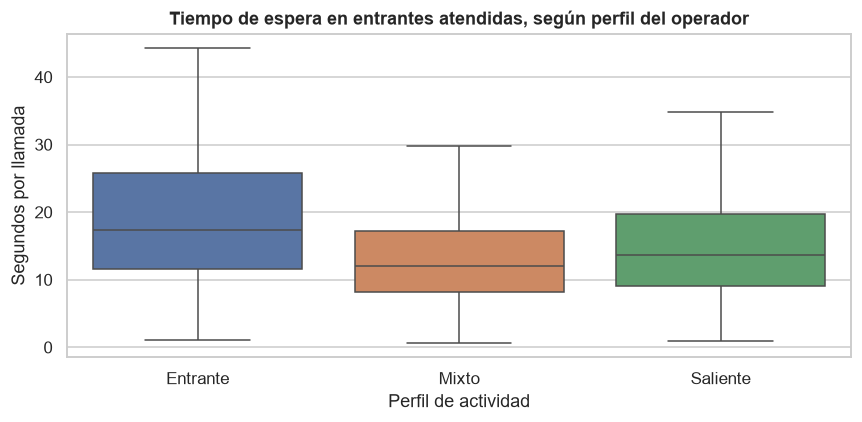

In [20]:
if p_h1 < ALFA:
    from itertools import combinations
    from statsmodels.stats.multitest import multipletests

    pares = list(combinations(range(3), 2))
    brutos = [stats.mannwhitneyu(grupos_h1[i], grupos_h1[j]).pvalue for i, j in pares]
    rechaza, ajustados, _, _ = multipletests(brutos, alpha=ALFA, method='holm')

    print('Comparaciones por pares (Mann-Whitney, corrección de Holm):\n')
    for (i, j), pb, pa, r in zip(pares, brutos, ajustados, rechaza):
        print(f'  {perfiles[i]:<9} vs {perfiles[j]:<9}  p={pb:.4f}  p_ajustado={pa:.4f}  '
              f'{"DIFERENCIA SIGNIFICATIVA" if r else "sin diferencia"}')

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=h1_datos, x='perfil', y='espera_media', order=perfiles,
            hue='perfil', palette='deep', legend=False, showfliers=False, ax=ax)
ax.set_title('Tiempo de espera en entrantes atendidas, según perfil del operador')
ax.set_xlabel('Perfil de actividad')
ax.set_ylabel('Segundos por llamada')
plt.tight_layout()
plt.show()

**Conclusión de la hipótesis 1.** Se rechaza la hipótesis nula: el tiempo de espera **no es igual entre perfiles**, y la diferencia va en el sentido contrario al que cabría esperar. Los operadores especializados en atender llamadas entrantes son los que hacen esperar **más**, no menos.

La interpretación de negocio es que **la especialización no está funcionando como mecanismo de mejora del servicio**: quienes concentran la atención telefónica están saturados. La conclusión práctica no es formar mejor a esos operadores, sino revisar cómo se reparte la carga de llamadas entrantes dentro de cada equipo.

## 6.3 Hipótesis 2 — Plan tarifario y pérdida de llamadas

> **H₀:** la tasa de pérdida en llamadas entrantes es igual entre los clientes de los planes A, B y C.
> **H₁:** al menos un plan presenta una tasa de pérdida distinta.

In [21]:
planes = ['A', 'B', 'C']
grupos_h2 = [cli.loc[cli['tariff_plan'] == p, 'tasa_perdida'] for p in planes]

print('Tasa de pérdida de llamadas entrantes por plan:')
print(cli.groupby('tariff_plan')['tasa_perdida']
      .agg(clientes='size', mediana='median', media='mean').round(3).to_string(), '\n')

parametrica_h2 = verificar_supuestos(grupos_h2, planes, 'Supuestos — Hipótesis 2')

if parametrica_h2:
    est2, p_h2 = stats.f_oneway(*grupos_h2)
    prueba_h2 = 'ANOVA'
else:
    est2, p_h2 = stats.kruskal(*grupos_h2)
    prueba_h2 = 'Kruskal-Wallis'

print(f'{prueba_h2}: estadístico = {est2:.3f}, p = {p_h2:.3e}')
print(f'Decisión: {"SE RECHAZA H0" if p_h2 < ALFA else "NO se rechaza H0"} (α = {ALFA})')

Tasa de pérdida de llamadas entrantes por plan:
             clientes  mediana  media
tariff_plan                          
A                  31    0.409  0.513
B                  84    0.628  0.608
C                 113    0.407  0.460 

Supuestos — Hipótesis 2
-----------------------
  Shapiro-Wilk A          n=  31  p=1.61e-02  NO normal
  Shapiro-Wilk B          n=  84  p=7.58e-03  NO normal
  Shapiro-Wilk C          n= 113  p=3.26e-05  NO normal
  Levene (varianzas)        p=0.7388  homogéneas
  => Kruskal-Wallis (no paramétrica)

Kruskal-Wallis: estadístico = 16.111, p = 3.173e-04
Decisión: SE RECHAZA H0 (α = 0.05)


Comparaciones por pares (Mann-Whitney, corrección de Holm):

  Plan A vs Plan B  p=0.0836  p_ajustado=0.1671  sin diferencia
  Plan A vs Plan C  p=0.3395  p_ajustado=0.3395  sin diferencia
  Plan B vs Plan C  p=0.0001  p_ajustado=0.0002  DIFERENCIA SIGNIFICATIVA


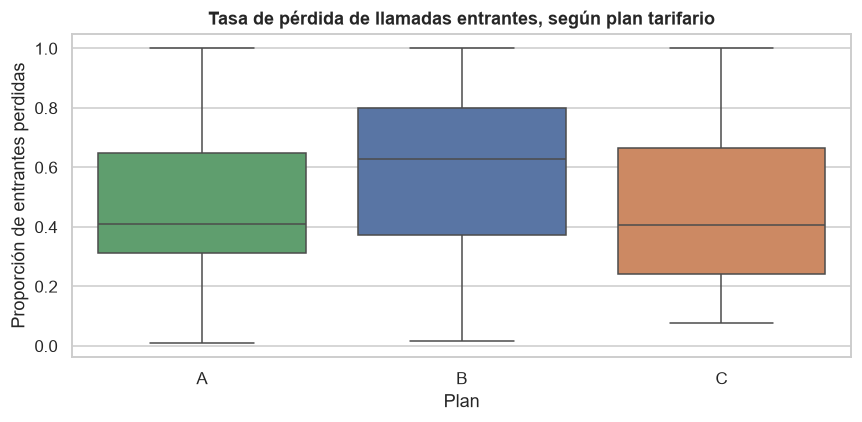

In [22]:
if p_h2 < ALFA:
    from itertools import combinations
    from statsmodels.stats.multitest import multipletests

    pares2 = list(combinations(range(3), 2))
    brutos2 = [stats.mannwhitneyu(grupos_h2[i], grupos_h2[j]).pvalue for i, j in pares2]
    rechaza2, ajustados2, _, _ = multipletests(brutos2, alpha=ALFA, method='holm')

    print('Comparaciones por pares (Mann-Whitney, corrección de Holm):\n')
    for (i, j), pb, pa, r in zip(pares2, brutos2, ajustados2, rechaza2):
        print(f'  Plan {planes[i]} vs Plan {planes[j]}  p={pb:.4f}  p_ajustado={pa:.4f}  '
              f'{"DIFERENCIA SIGNIFICATIVA" if r else "sin diferencia"}')

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=cli, x='tariff_plan', y='tasa_perdida', order=planes,
            hue='tariff_plan', palette='deep', legend=False, ax=ax)
ax.set_title('Tasa de pérdida de llamadas entrantes, según plan tarifario')
ax.set_xlabel('Plan')
ax.set_ylabel('Proporción de entrantes perdidas')
plt.tight_layout()
plt.show()

**Conclusión de la hipótesis 2.** Se rechaza la hipótesis nula: la pérdida de llamadas **no es igual entre planes**. El análisis por pares precisa dónde está la diferencia: es **significativa entre los planes B y C**, mientras que las comparaciones que involucran al plan A no alcanzan significación tras la corrección de Holm. Con solo 31 clientes, el plan A aporta poca potencia estadística, de modo que su resultado no debe leerse como ausencia de diferencia sino como ausencia de evidencia suficiente.

El hallazgo firme es, por tanto, que **los clientes del plan B pierden una proporción sustancialmente mayor de llamadas entrantes que los del plan C** (mediana del 63% frente al 41%).

Esto desplaza parte del diagnóstico fuera del desempeño individual: si un cliente del plan B pierde más llamadas, **evaluar a sus operadores no resolverá el problema**. Conviene revisar qué diferencia operativa introduce ese plan —capacidad de líneas simultáneas, reglas de distribución de llamadas o dimensionamiento del equipo contratado— antes de atribuir el resultado a las personas.

Un matiz que refuerza esta lectura: los clientes del plan B tienen una mediana de operadores similar a la del plan C pero gestionan un volumen de entrantes parecido, lo que sugiere que la diferencia no se explica simplemente por tener equipos más pequeños.

---
# 7. Conclusiones y recomendaciones

## 7.1 Qué muestran los datos

In [23]:
ent_total = entrantes['calls_count'].sum()
ent_perdidas = entrantes.loc[entrantes['is_missed_call'], 'calls_count'].sum()
n_inef = int(evaluables['ineficaz'].sum())

print('=' * 66)
print('RESUMEN EJECUTIVO'.center(66))
print('=' * 66)
print(f'Período analizado           : {llamadas["fecha"].min()} a {llamadas["fecha"].max()}')
print(f'Clientes activos            : {llamadas["user_id"].nunique()}')
print(f'Llamadas analizadas         : {llamadas["calls_count"].sum():,}')
print('-' * 66)
print(f'Llamadas entrantes          : {ent_total:,}')
print(f'  perdidas                  : {ent_perdidas:,} ({ent_perdidas/ent_total:.1%})')
print(f'  sin operador atribuible   : {entrantes.loc[entrantes["is_missed_call"] & entrantes["operator_id"].isna(), "calls_count"].sum():,}')
print('-' * 66)
print(f'Operadores evaluados        : {len(evaluables):,}')
print(f'Señalados como ineficaces   : {n_inef} ({n_inef/len(evaluables):.1%})')
print(f'  volumen que gestionan     : {evaluables.loc[evaluables["ineficaz"], "llamadas"].sum()/evaluables["llamadas"].sum():.1%} del total')
print(f'  clientes afectados        : {evaluables.loc[evaluables["ineficaz"], "cliente"].nunique()}')
print('-' * 66)
print(f'H1 espera según perfil      : p = {p_h1:.2e}  -> {"se rechaza H0" if p_h1 < ALFA else "no se rechaza"}')
print(f'H2 pérdida según plan       : p = {p_h2:.2e}  -> {"se rechaza H0" if p_h2 < ALFA else "no se rechaza"}')
print('=' * 66)

                        RESUMEN EJECUTIVO                         
Período analizado           : 2019-08-02 a 2019-11-28
Clientes activos            : 307
Llamadas analizadas         : 806,709
------------------------------------------------------------------
Llamadas entrantes          : 197,845
  perdidas                  : 104,323 (52.7%)
  sin operador atribuible   : 103,397
------------------------------------------------------------------
Operadores evaluados        : 720
Señalados como ineficaces   : 91 (12.6%)
  volumen que gestionan     : 1.2% del total
  clientes afectados        : 49
------------------------------------------------------------------
H1 espera según perfil      : p = 3.15e-05  -> se rechaza H0
H2 pérdida según plan       : p = 3.17e-04  -> se rechaza H0


## 7.2 Conclusiones

**1. El problema principal del servicio no está en los operadores individuales.** Más de la mitad de las llamadas entrantes se pierden, y el 99% de esas pérdidas no puede atribuirse a ninguna persona: son llamadas que ningún operador llegó a atender. Es un problema de **cobertura**, no de desempeño.

**2. La función solicitada es viable, pero su impacto es limitado.** Sí es posible identificar operadores con desempeño deficiente de forma reproducible, y el grupo señalado es claramente distinto del resto: espera aproximadamente el doble por llamada y gestiona una fracción del volumen diario de sus pares. Ahora bien, en conjunto mueven apenas el 1,2% del tráfico, de modo que corregirlos **no resolverá el problema de las llamadas perdidas**.

**3. La especialización en llamadas entrantes está asociada a peores tiempos de espera** (hipótesis 1, contrastada; los tres perfiles difieren entre sí tras la corrección de Holm). Quienes se dedican a atender son quienes más hacen esperar —una mediana de 17,4 segundos frente a 12,0 de los mixtos—, lo que apunta a saturación por reparto desigual de la carga y no a falta de aptitud.

**4. El plan tarifario condiciona la calidad del servicio** (hipótesis 2, contrastada). Los clientes del plan B pierden significativamente más llamadas entrantes que los del plan C. Evaluar a sus operadores sería atribuir a las personas un efecto que procede de las condiciones del servicio contratado.

**5. Los datos no registran quién debía atender una llamada perdida.** Esta es la limitación de fondo del caso: sin ese dato, la señal que el propio enunciado sitúa en primer lugar es inmedible a nivel individual. Corregirlo es la condición para que la función solicitada alcance su propósito.

In [24]:
# Exportación de resultados para la presentación
evaluables.to_csv(RUTA_PROCESSED + 'operadores_evaluados.csv')
ranking.to_csv(RUTA_PROCESSED + 'ranking_ineficaces.csv')
cli.to_csv(RUTA_PROCESSED + 'clientes_perdida.csv')
llamadas.to_csv(RUTA_INTERIM + 'llamadas_limpio.csv', index=False)

# Extracto para el dashboard de Tableau: una fila por registro, con las
# columnas ya derivadas para que en Tableau baste con arrastrar campos.
extracto = llamadas.assign(
    duracion_por_llamada=llamadas['call_duration'] / llamadas['calls_count'],
    espera_por_llamada=llamadas['espera'] / llamadas['calls_count'],
    estado=np.where(llamadas['is_missed_call'], 'Perdida', 'Contestada'),
    # Int64 (entero anulable) evita que Tableau lea los identificadores como
    # decimales y que las filas sin operador aparezcan como "nan"
    operador=llamadas['operator_id'].astype('Int64'),
)[['fecha', 'user_id', 'operador', 'tariff_plan', 'sentido', 'tipo', 'estado',
   'calls_count', 'call_duration', 'total_call_duration', 'espera',
   'duracion_por_llamada', 'espera_por_llamada']].rename(columns={
    'fecha': 'Fecha', 'user_id': 'Cliente', 'operador': 'Operador',
    'tariff_plan': 'Plan tarifario', 'sentido': 'Direccion', 'tipo': 'Tipo de llamada',
    'estado': 'Estado', 'calls_count': 'Numero de llamadas',
    'call_duration': 'Duracion total (s)', 'total_call_duration': 'Duracion con espera (s)',
    'espera': 'Espera total (s)', 'duracion_por_llamada': 'Duracion por llamada (s)',
    'espera_por_llamada': 'Espera por llamada (s)'})

extracto.round(2).to_csv('dashboard/tableau_extract.csv', index=False, encoding='utf-8-sig')

print('Archivos generados:')
print(f'  data/processed/operadores_evaluados.csv  ({len(evaluables):,} operadores)')
print(f'  data/processed/ranking_ineficaces.csv    ({len(ranking):,} señalados)')
print(f'  data/processed/clientes_perdida.csv      ({len(cli):,} clientes)')
print(f'  data/interim/llamadas_limpio.csv         ({len(llamadas):,} registros)')
print(f'  dashboard/tableau_extract.csv            ({len(extracto):,} filas, {extracto.shape[1]} columnas)')

Archivos generados:
  data/processed/operadores_evaluados.csv  (720 operadores)
  data/processed/ranking_ineficaces.csv    (91 señalados)
  data/processed/clientes_perdida.csv      (228 clientes)
  data/interim/llamadas_limpio.csv         (49,002 registros)
  dashboard/tableau_extract.csv            (49,002 filas, 13 columnas)


---
# 8. Fuentes consultadas

| # | Fuente | Qué pregunta ayudó a resolver |
|---|---|---|
| 1 | [pandas — Duplicate labels and `drop_duplicates`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html) | Cómo distinguir duplicados exactos de repeticiones de clave con métricas distintas, que fue la comprobación que decidió eliminarlos |
| 2 | [pandas — Time zone handling](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-zone-handling) | Cómo tratar el desfase `+03:00` de la columna `date` sin desplazar registros de día al agrupar |
| 3 | [`Series.rank(pct=True)` — pandas](https://pandas.pydata.org/docs/reference/api/pandas.Series.rank.html) | Cómo construir un índice comparable entre operadores con distinto número de dimensiones medibles |
| 4 | [SciPy — Shapiro-Wilk](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html) y [Levene](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html) | Cómo verificar formalmente los supuestos antes de elegir entre ANOVA y una prueba no paramétrica |
| 5 | [SciPy — Kruskal-Wallis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html) | Qué prueba usar para comparar tres grupos independientes cuando la distribución es fuertemente asimétrica |
| 6 | [statsmodels — `multipletests`](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html) | Cómo corregir el nivel de significación al hacer tres comparaciones por pares (método de Holm) |
| 7 | [Holm, S. (1979). *A Simple Sequentially Rejective Multiple Test Procedure*](https://www.jstor.org/stable/4615733) | Por qué la corrección de Holm es preferible a Bonferroni al tener mayor potencia manteniendo el control del error de tipo I |
| 8 | [Call Centre Helper — Abandoned and missed call metrics](https://www.callcentrehelper.com/abandon-rate-6412.htm) | Qué se considera una tasa de abandono habitual en centros de llamadas, para dimensionar si el 52% observado es anómalo |
| 9 | [seaborn — Statistical data visualization](https://seaborn.pydata.org/tutorial.html) | Cómo representar distribuciones muy asimétricas de forma legible (escala logarítmica y supresión de valores extremos en los diagramas de caja) |